In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import matplotlib.patches as mpatches
import xeofs as xf
from tqdm import tqdm
from cartopy.feature import LAND
from gsw import geostrophy
from scipy.optimize import minimize


In [4]:
fetan = '../data/SOSE/SSH_bsoseI166_2013to2024_monthly_adelie.nc'
fsnow = '../data/SOSE/SIhsnow_bsoseI166_2013to2024_monthly_adelie.nc'
farea = '../data/SOSE/SIArea_bsoseI166_2013to2024_monthly_adelie.nc'
fheff = '../data/SOSE/SIHeff_bsoseI166_2013to2024_monthly_adelie.nc'


In [5]:
etan = xr.open_dataarray(fetan)
snow = xr.open_dataarray(fsnow)
area = xr.open_dataarray(farea)
heff = xr.open_dataarray(fheff)

In [6]:
rho_w = 1028.5
rho_ice = 910
rho_snow = 330

sload = (heff * rho_ice) + (snow * rho_snow)

sload = sload / rho_w

# correct SSH for loading
sose_ssh = (etan + sload)

# compute SOSE ssh anomaly wrt to same mean as SLA
# etan = etan - etan.sel(time=slice(t1,t2)).mean('time')
# etan = etan.resample({'time':'MS'}).mean()


In [7]:
extent = [138,152,-69,-63]
extent_mi = [20,180,-74,-50]

In [8]:
ssh=sose_ssh.rename({'XC':'longitude','YC':'latitude'})
ssh=ssh.where(~(ssh==0))
ssh=fns.crop_to_extent(ssh,extent)
ssh=ssh.mean('time')


In [9]:
etn=etan.rename({'XC':'longitude','YC':'latitude'})
etn=etn.where(~(etn==0))
etn=fns.crop_to_extent(etn,extent)
etn=etn.mean('time')


In [10]:
load=sload.rename({'XC':'longitude','YC':'latitude'})
load=load.where(~(load==0))
load=load.mean('time')
load=fns.crop_to_extent(load,extent)

Text(0.5, 1.0, 'loading')

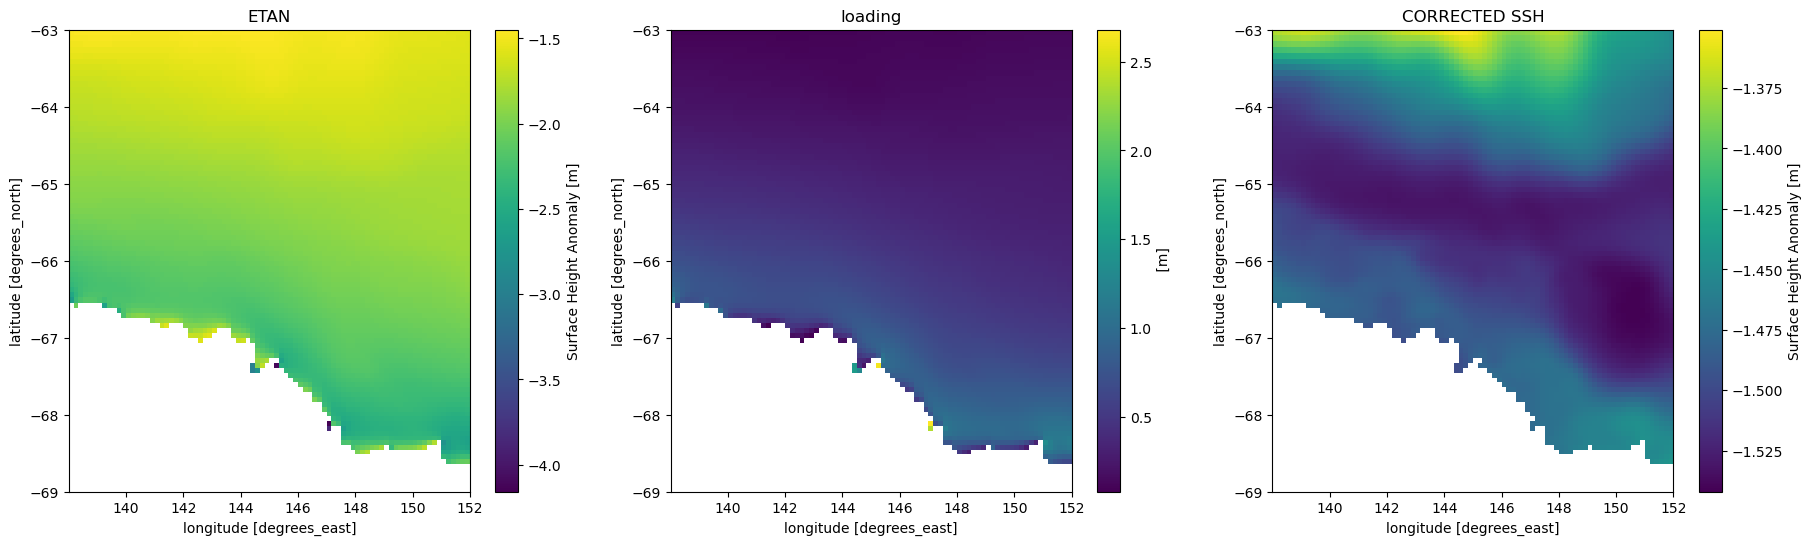

In [11]:
fig, ax = plt.subplots(1,3,figsize=(22,6))

ssh.plot(ax=ax[2],y='latitude',x='longitude')#,vmin=-3,vmax=1)
ax[2].set_title('CORRECTED SSH')
etn.plot(ax=ax[0],y='latitude',x='longitude')
ax[0].set_title('ETAN')
load.plot(ax=ax[1],y='latitude',x='longitude')
ax[1].set_title('loading')

In [12]:
sla_ = SLA(deg=0.25).da
elevation_ = GEBCO(coarsen_factor=40).ds.elevation
sice_ = xr.open_dataset('../data/NSIDC/sice_processed.nc').__xarray_dataarray_variable__
winds_ = xr.open_dataset('../data/ef25db236e60a21a34ee2e0b4631d366.nc').sortby('latitude').rename({'valid_time':'time'})
sam = Index(type='SAM').da.sel(time=slice(sla_.time[0],sla_.time[-1]))
dsice_ = sice_.differentiate('time') * 1e9 * 60 * 60 * 24 #convert to day
dot_ = DOT().ds.dot

In [13]:
winds_.u10

<xarray.DataArray 'u10' (time: 252, latitude: 161, longitude: 1440)> Size: 234MB
[58423680 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2023-12-01
    expver     (time) <U4 4kB ...
  * latitude   (latitude) float64 1kB -90.0 -89.75 -89.5 ... -50.5 -50.25 -50.0
  * longitude  (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number     int64 8B ...
Attributes: (12/32)
    GRIB_paramId:                             165
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      231840
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgua
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                10 metre U wind component
    units:                                    m s**-1
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [14]:
westerly_range = winds_.u10.sel(latitude=slice(-65,-55))
weights = np.cos(np.deg2rad(westerly_range.latitude))
westl = westerly_range.weighted(weights).mean(dim=["latitude", "longitude"])

In [15]:
sose_ssh = sose_ssh.rename({'XC':'longitude','YC':'latitude'}).drop_vars(['rA','iter','Depth','maskInC','rSurfC','rLowC'])
sose_ssh['month'] = sose_ssh.time.dt.month

In [16]:

elevation = elevation_.sel(latitude = slice(extent_mi[2], extent_mi[3]), longitude = slice(extent_mi[0],extent_mi[1]))

extent_totten =[114,122, -68,-65] # no data before 2015??
extent_vincennes = [102,112,-68,-64]

In [17]:
# def evr(x4):
#     x1=134
#     x2=148
#     x3=-67
#     region = Region('Adelie',[x1,x2,x3,x4[0]],elevation=elevation)#,min_elevation=-1000)
#     sla = region.crop_da(sla_)
#     sice = region.crop_da(sice_)
#     winds = region.crop_da(winds_)
#     da_sic = fns.seasonal_anomaly(sice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
#     da_sla = fns.seasonal_anomaly(sla.interpolate_na(dim='time'))
#     da_u10 = fns.seasonal_anomaly(winds.u10.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
#     da_v10 = fns.easonal_anomaly(winds.v10.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
#     multivariate_data = [da_sic, da_sla, da_u10, da_v10]
#     pca = xf.single.EOF(n_modes=1, standardize=False, use_coslat=True)
#     pca.fit(multivariate_data, dim="time")
#     return pca.explained_variance_ratio().item()

# # Run optimizatio
# res = minimize(lambda x: -evr(x), [-61], method='Nelder-Mead', bounds=[(-63,-60)],options={"disp": True})

# print("Best inputs:", res.x)
# print("Maximum EVR:", evr(res.x))

In [18]:
t0 = sose_ssh.time[0]
t1 = sla_.time[-1]

westl = fns.seasonal_anomaly(westl.sel(time=slice(t0,t1)))

In [19]:
def prepare_data(extent):
    region = Region('Adelie',extent,elevation=elevation)#,min_elevation=-1000) #130,148,-67,-61.5
    sla = region.crop_da(sla_)
    #sice = region.crop_da(sice_)
    winds = region.crop_da(winds_)
    ssh = region.crop_da(sose_ssh)
    #dot = region.crop_da(dot_)
    #dsice = region.crop_da(dsice_)
    #da_sic = seasonal_anomaly(sice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
    #da_dsc = seasonal_anomaly(dsice.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
    #da_dot = seasonal_anomaly(dot.interpolate_na(dim='time')
    da_sla = fns.seasonal_anomaly(sla.interpolate_na(dim='time').sel(time=slice(t0,t1)))
    da_u10 = fns.seasonal_anomaly(winds.u10.interpolate_na(dim='time').sel(time=slice(t0,t1))).drop_vars(['number','expver'])
    da_v10 = fns.seasonal_anomaly(winds.v10.interpolate_na(dim='time').sel(time=slice(t0,t1))).drop_vars(['number','expver'])
    da_sose = fns.seasonal_anomaly(ssh.interpolate_na(dim='time').sel(time=slice(t0,t1)))
    #da_msl = seasonal_anomaly(winds.msl.interpolate_na(dim='time').sel(time=slice(sla.time[0],sla.time[-1])))
    # fig,ax = plt.subplots(figsize=(6,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
    # pfns.sp(ax=ax,da=sice.mean('time'),extent=extent,cbar='SIC mean')
    return [da_sla,da_u10,da_v10,da_sose]

In [20]:
multivariate_data = prepare_data(extent)
multivariate_data_mi = prepare_data(extent_mi)
sla_data = multivariate_data[0]
sla_data_mi = multivariate_data_mi[0]
sose_data = multivariate_data[3]
sose_data_mi = multivariate_data_mi[3]


In [21]:
def eof_for_data(data):
    pca = xf.single.EOF(n_modes=4, standardize=True, use_coslat=True)
    pca.fit(data, dim="time")
    components = pca.components()
    scores = pca.scores()
    evr=pca.explained_variance_ratio()
    return components, scores, evr


In [22]:
# fig,axs = plt.subplots(3,4,figsize=(20,14),subplot_kw={'projection':ccrs.SouthPolarStereo()})

# # plot maps
# def plot_component(ax,component,title,mode):
#     comp=component.sel(mode=mode)
#     evr_=evr.sel(mode=mode).item()
#     comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
#     ax.set_extent(extent,crs=ccrs.PlateCarree())
#     ax.add_feature(LAND, edgecolor='k')
#     ax.gridlines(draw_labels=True)
#     elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
#     ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

# for i, row in enumerate(axs) :
#     plot_component(row[0],components[0],'SIC',mode=i+1)
#     plot_component(row[1],components[1],'SLA',mode=i+1)
#     plot_component(row[2],components[2],'u10',mode=i+1)
#     plot_component(row[3],components[3],'v10',mode=i+1)



In [23]:
#cmpnt_mv_mi, scrs_mv_mi, evr_mv_mi = eof_for_data(multivariate_data_mi[:2])
#cmpnt_mv, scrs_mv, evr_mv = eof_for_data(multivariate_data[:2])

cmpnt_s_mi, scrs_s_mi, evr_s_mi = eof_for_data(sla_data_mi)
cmpnt_s, scrs_s, evr_s = eof_for_data(sla_data)


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xeofs/preprocessing/multi_index_converter.py:49: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'dim2', 'dim1'} to avoid an error in the future.
  X_transformed = X_transformed.drop_vars(dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xeofs/preprocessing/multi_index_converter.py:49: FutureWarning: Deleting a single level of a Mu

In [24]:
cmpnt_s_mi_sose, scrs_s_mi_sose, evr_s_mi_sose = eof_for_data(sose_data_mi)
cmpnt_s_sose, scrs_s_sose, evr_s_sose = eof_for_data(sose_data)

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xeofs/preprocessing/multi_index_converter.py:49: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'dim2', 'dim1'} to avoid an error in the future.
  X_transformed = X_transformed.drop_vars(dim)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xeofs/preprocessing/multi_index_converter.py:49: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'dim2', 'dim1'} to avoid an error in the future.
  X_transformed = X_transformed.drop_vars(dim)


In [25]:

#cmpnt_mv_mi_sose, scrs_mv_mi_sose, evr_mv_mi_sose = eof_for_data(multivariate_data_mi[1:])
#cmpnt_mv_sose, scrs_mv_sose, evr_mv_sose = eof_for_data(multivariate_data[1:])



In [26]:
# fig,axs = plt.subplots(2,1,figsize=(16,10),subplot_kw={'projection':ccrs.Mercator()})

# # plot maps
# def plot_component(ax,component,title,mode,evr):
#     comp=component.sel(mode=mode)
#     evr_=evr.sel(mode=mode).item()
#     comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
#     ax.set_extent(extent_mi,crs=ccrs.PlateCarree())
#     ax.add_feature(LAND, edgecolor='k')
#     ax.gridlines(draw_labels=True)
#     elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
#     ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

# plot_component(axs[0],cmpnt_mv_mi[0],'SLA (Multivariate)',mode=1,evr=evr_mv_mi)
# plot_component(axs[1],cmpnt_s_mi,'SLA',mode=1, evr = evr_s_mi)

# plt.tight_layout()


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWa

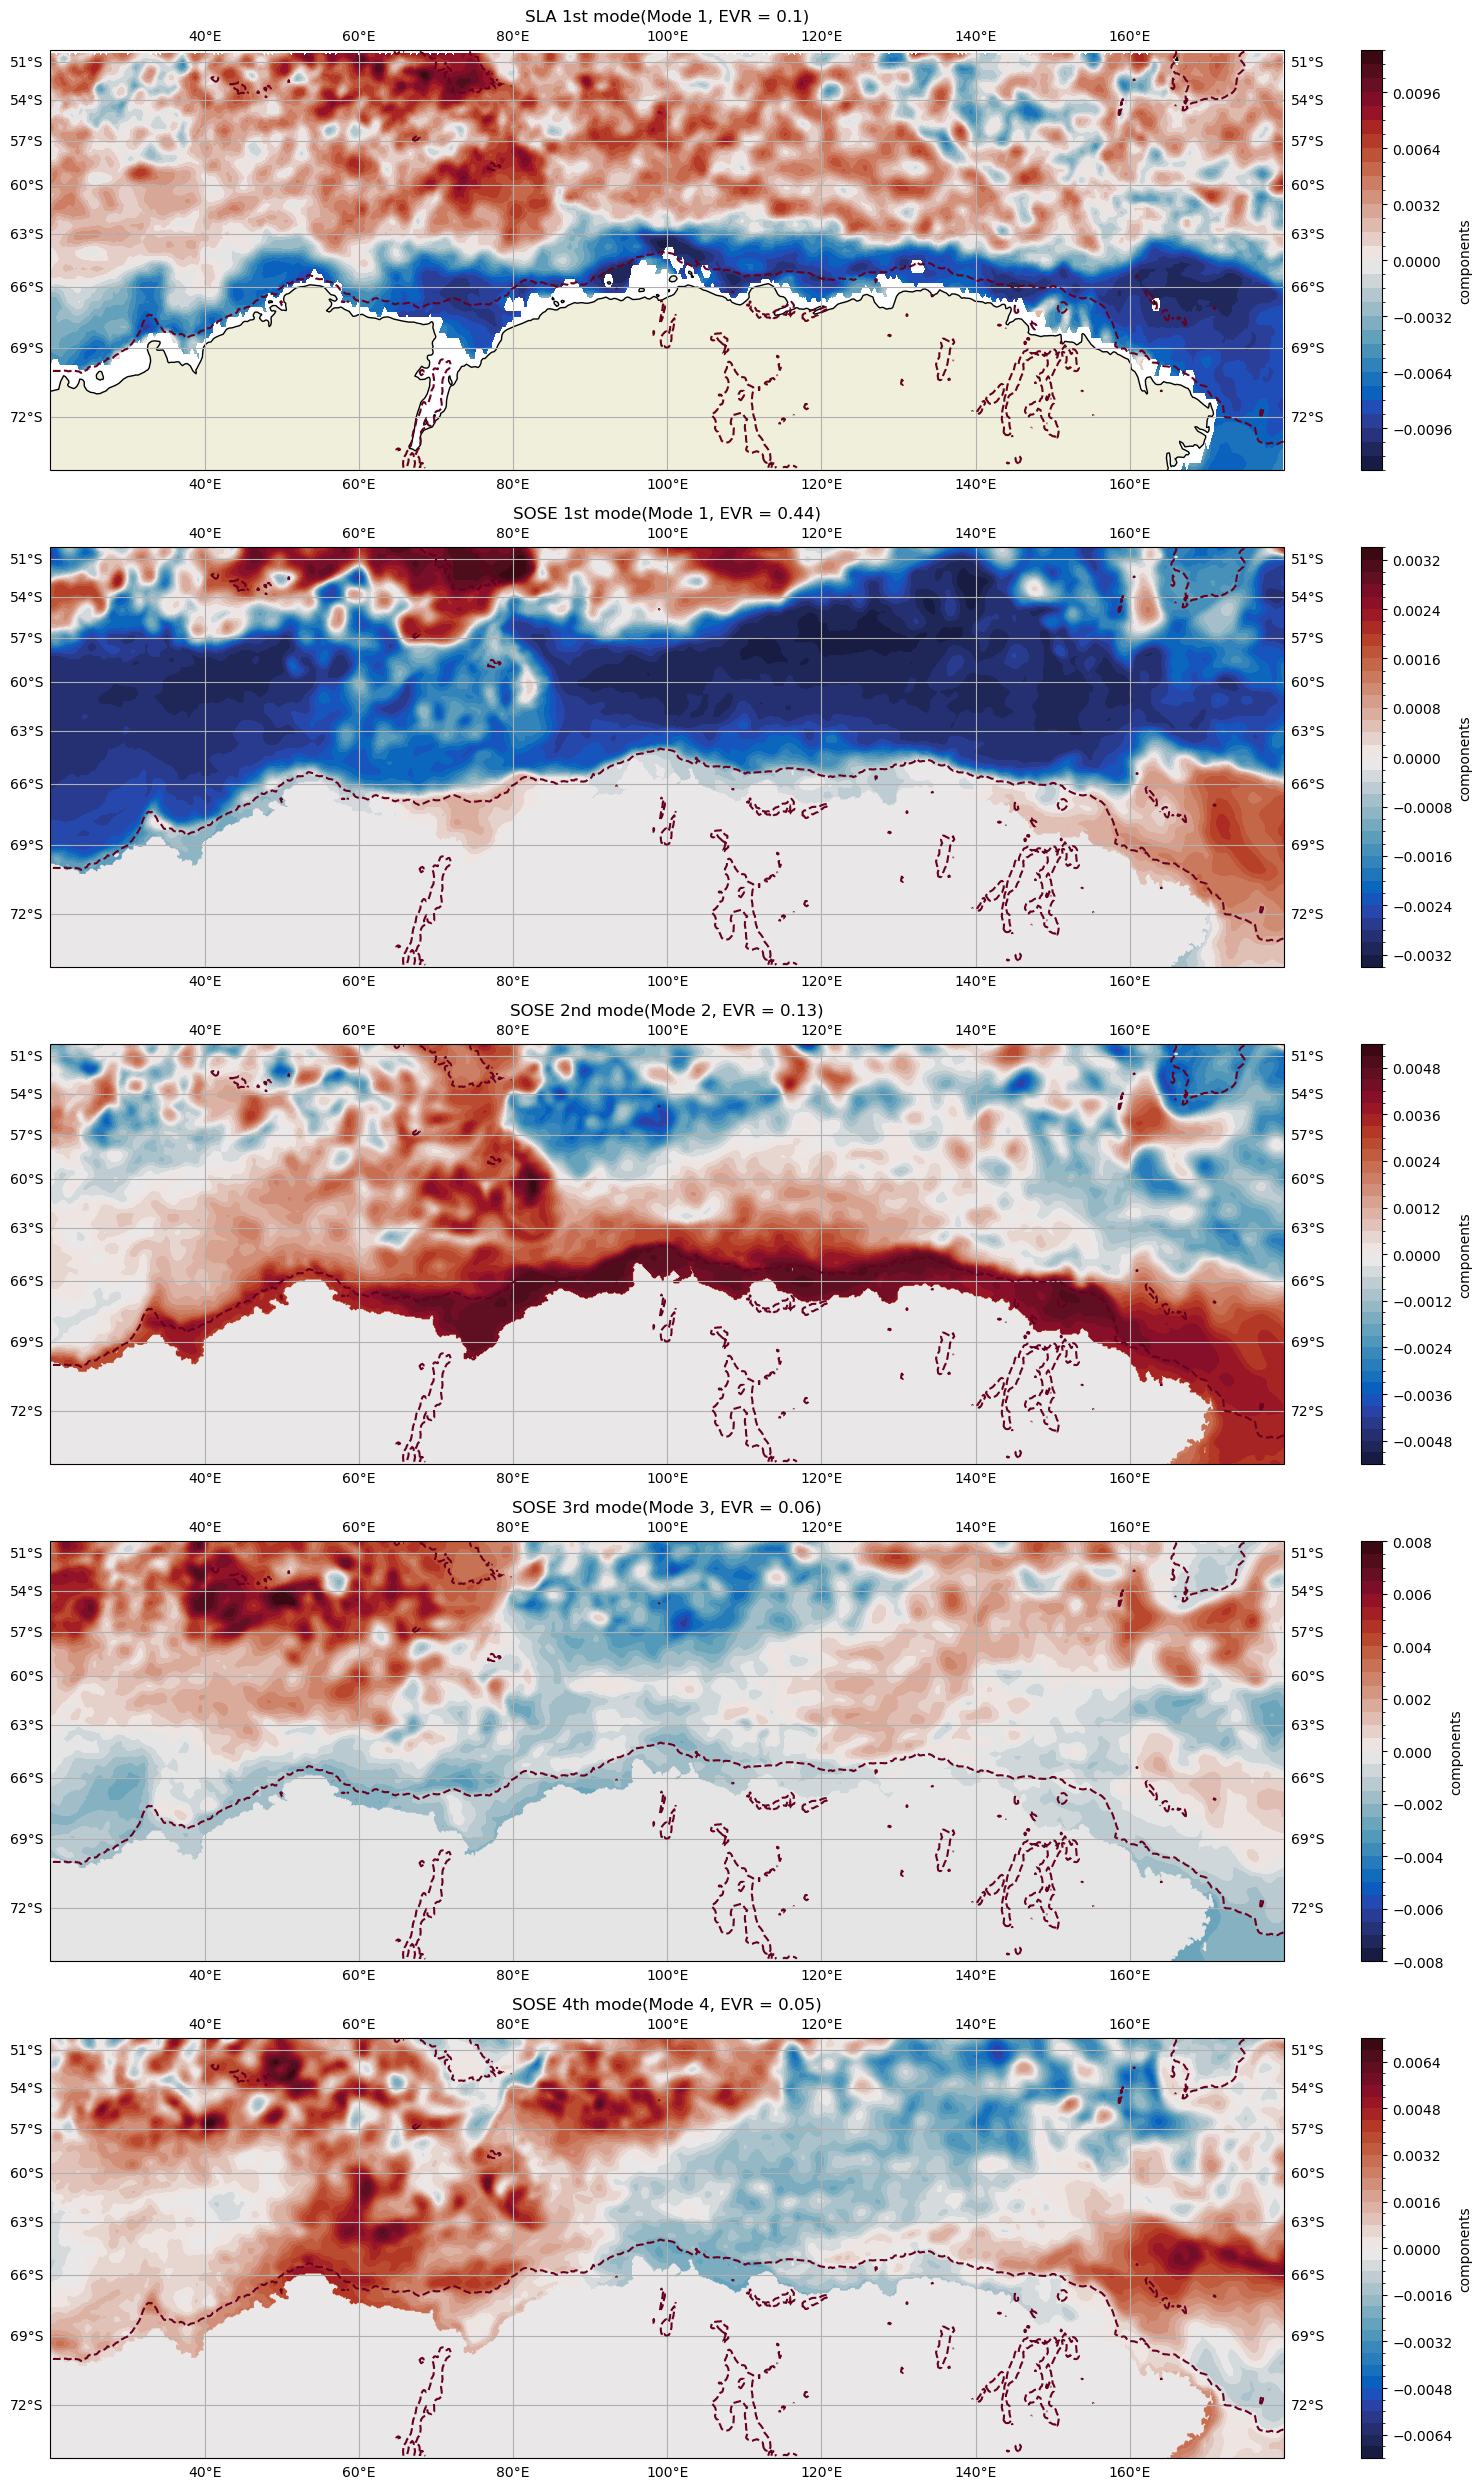

In [27]:
fig,axs = plt.subplots(5,1,figsize=(16,25),subplot_kw={'projection':ccrs.Mercator()})

# plot maps
def plot_component(ax,component,title,mode,evr):
    comp=component.sel(mode=mode)
    evr_=evr.sel(mode=mode).item()
    comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    ax.set_extent(extent_mi,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k')
    ax.gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
    ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

#plot_component(axs[0],cmpnt_mv_mi_sose[0],'SOSE (Multivariate) 1st mode',mode=1,evr=evr_mv_mi)
plot_component(axs[0],cmpnt_s_mi,'SLA 1st mode',mode=1, evr = evr_s_mi)
plot_component(axs[1],cmpnt_s_mi_sose,'SOSE 1st mode',mode=1, evr = evr_s_mi_sose)
plot_component(axs[2],cmpnt_s_mi_sose,'SOSE 2nd mode',mode=2, evr = evr_s_mi_sose)
plot_component(axs[3],cmpnt_s_mi_sose,'SOSE 3rd mode',mode=3, evr = evr_s_mi_sose)
plot_component(axs[4],cmpnt_s_mi_sose,'SOSE 4th mode',mode=4, evr = evr_s_mi_sose)



plt.tight_layout()


/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWa

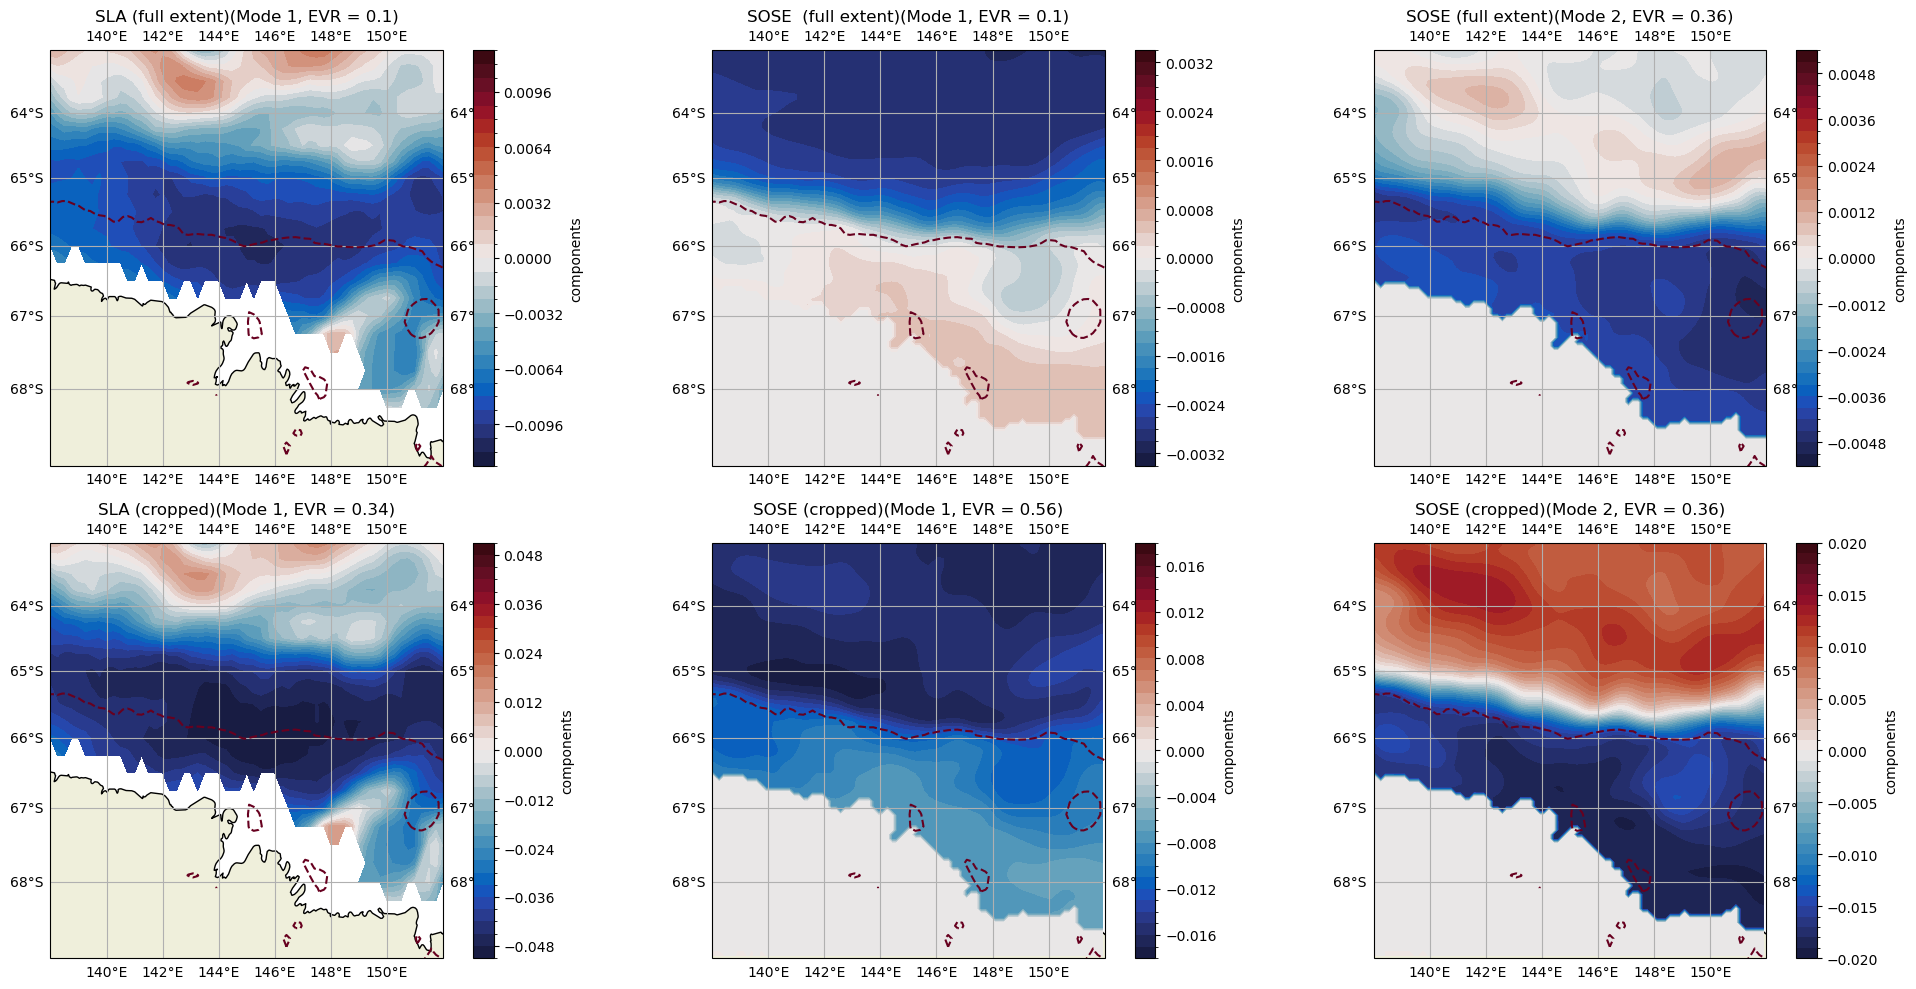

In [28]:
fig,axs = plt.subplots(2,3,figsize=(20,10),subplot_kw={'projection':ccrs.Mercator()})

extent2=[138,162,-69,-63]
# plot maps
def plot_component(ax,component,title,mode,evr):
    comp=component.sel(mode=mode)
    evr_=evr.sel(mode=mode).item()
    comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    ax.set_extent(extent,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k')
    ax.gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
    ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

plot_component(axs[0][0],cmpnt_s_mi,'SLA (full extent)',mode=1,evr=evr_s_mi)
plot_component(axs[0][1],cmpnt_s_mi_sose,'SOSE  (full extent)',mode=1, evr = evr_s_mi)
plot_component(axs[1][0],-cmpnt_s,'SLA (cropped)',mode=1,evr=evr_s)
plot_component(axs[1][1],-cmpnt_s_sose,'SOSE (cropped)',mode=1, evr = evr_s_sose)
plot_component(axs[0][2],-cmpnt_s_mi_sose,'SOSE (full extent)',mode=2, evr = evr_s_sose)
plot_component(axs[1][2],-cmpnt_s_sose,'SOSE (cropped)',mode=2, evr = evr_s_sose)


plt.tight_layout()

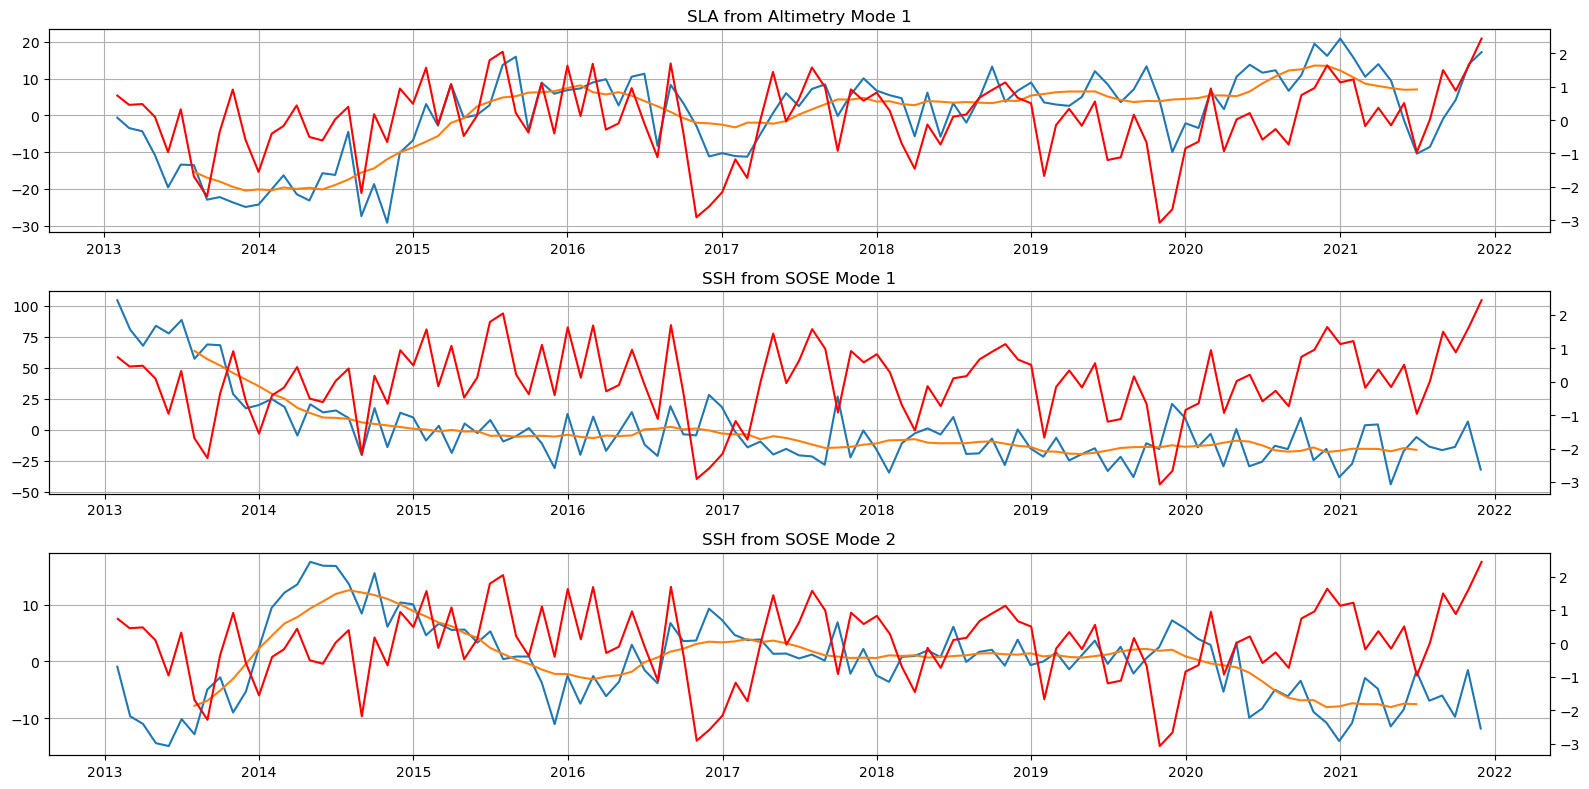

In [29]:
fig, axs = plt.subplots(3,1,figsize=(16,8))

axs[0].plot(scrs_s.time,-scrs_s.sel(mode=1))
axs[0].plot(scrs_s.time,-scrs_s.sel(mode=1).rolling({'time':12},center=True).mean())
axs[0].twinx().plot(westl.time,westl,c='r')
axs[0].set_title('SLA from Altimetry Mode 1')
axs[0].grid()

axs[1].plot(scrs_s_sose.time,-scrs_s_sose.sel(mode=2))
axs[1].plot(scrs_s_sose.time,-scrs_s_sose.sel(mode=2).rolling({'time':12},center=True).mean())
axs[1].twinx().plot(westl.time,westl,c='r')
axs[1].set_title('SSH from SOSE Mode 1')
axs[1].grid()

plt.tight_layout()

axs[2].plot(scrs_s_sose.time,-scrs_s_sose.sel(mode=3))
axs[2].plot(scrs_s_sose.time,-scrs_s_sose.sel(mode=3).rolling({'time':12},center=True).mean())
axs[2].twinx().plot(westl.time,westl,c='r')
axs[2].set_title('SSH from SOSE Mode 2')
axs[2].grid()

In [ ]:
-scrs_s.sel(mode=1).to_netcdf('sose_gi_mode1.nc')
-scrs_s.sel(mode=2).to_netcdf('sose_gi_mode2.nc')


/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning: The following kwargs were not used by contour: 'linestyle', 'c'
  result = super().contour(*args, **kwargs)


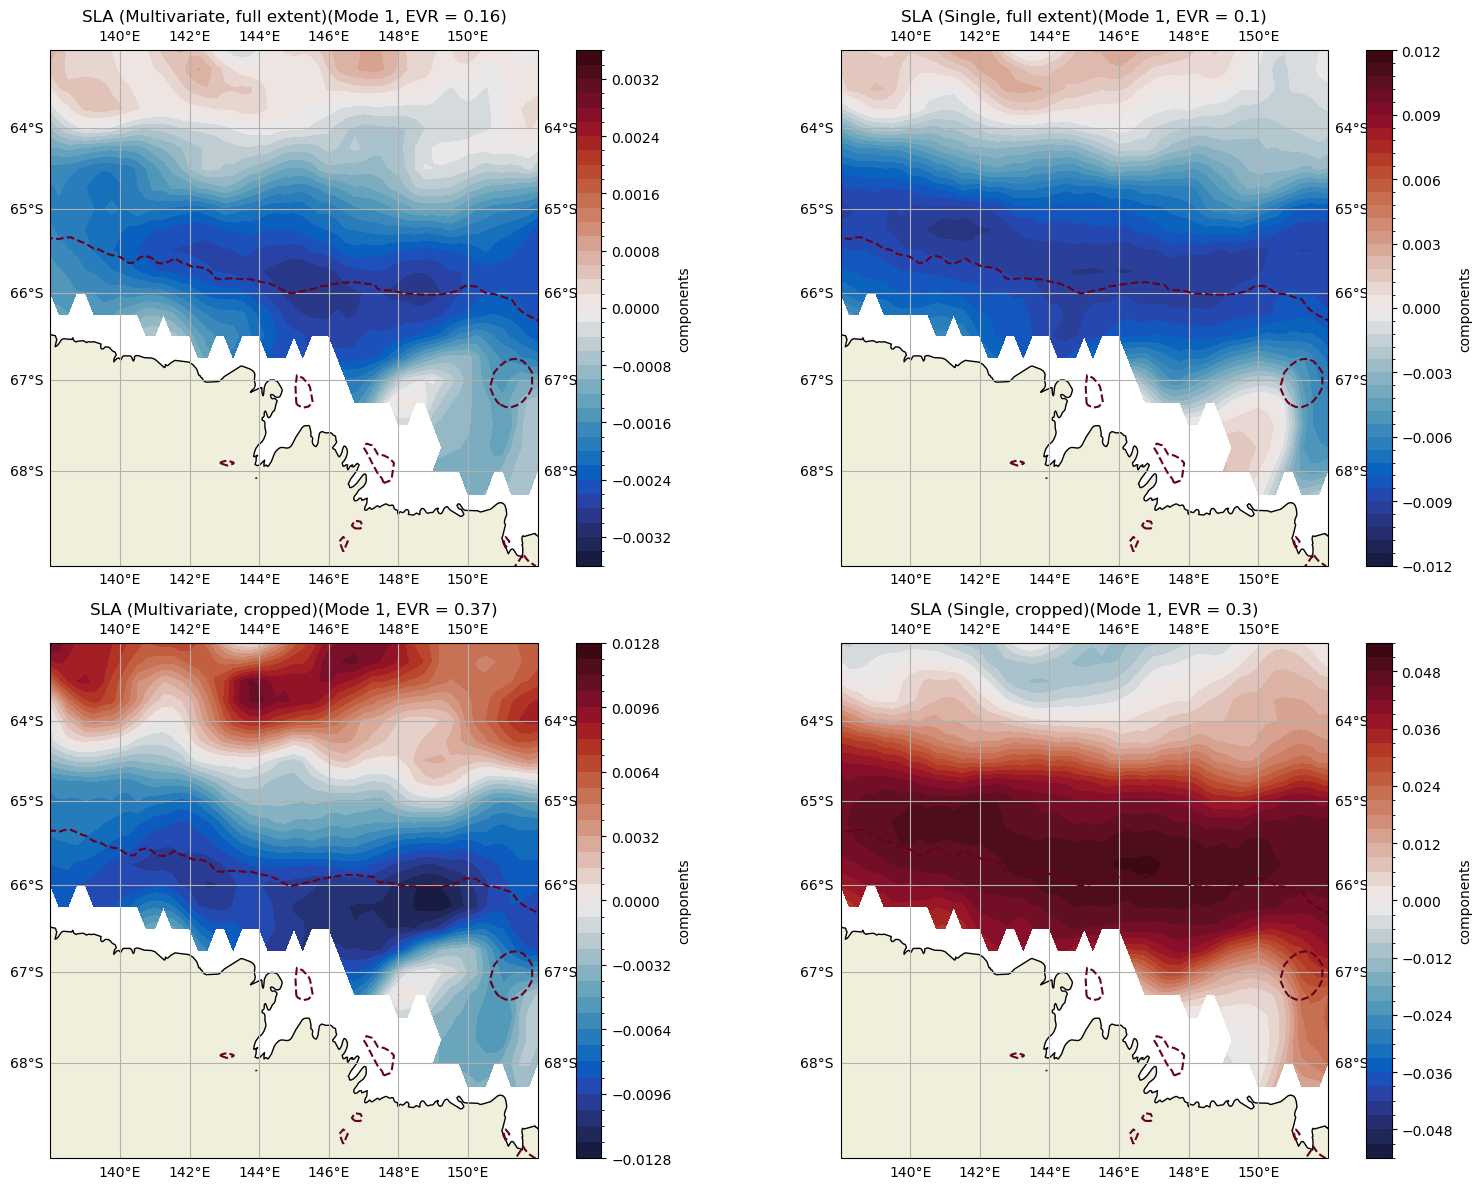

In [15]:
fig,axs = plt.subplots(2,2,figsize=(16,12),subplot_kw={'projection':ccrs.Mercator()})

# plot maps
def plot_component(ax,component,title,mode,evr):
    comp=component.sel(mode=mode)
    evr_=evr.sel(mode=mode).item()
    comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    ax.set_extent(extent,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k')
    ax.gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
    ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

plot_component(axs[0][0],components_mm[0],'SLA (Multivariate, full extent)',mode=1,evr=evr_mm)
plot_component(axs[0][1],components_sm,'SLA (Single, full extent)',mode=1, evr = evr_sm)
plot_component(axs[1][0],components_me[0],'SLA (Multivariate, cropped)',mode=1,evr=evr_me)
plot_component(axs[1][1],components_se,'SLA (Single, cropped)',mode=1, evr = evr_se)

plt.tight_layout()

/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning:

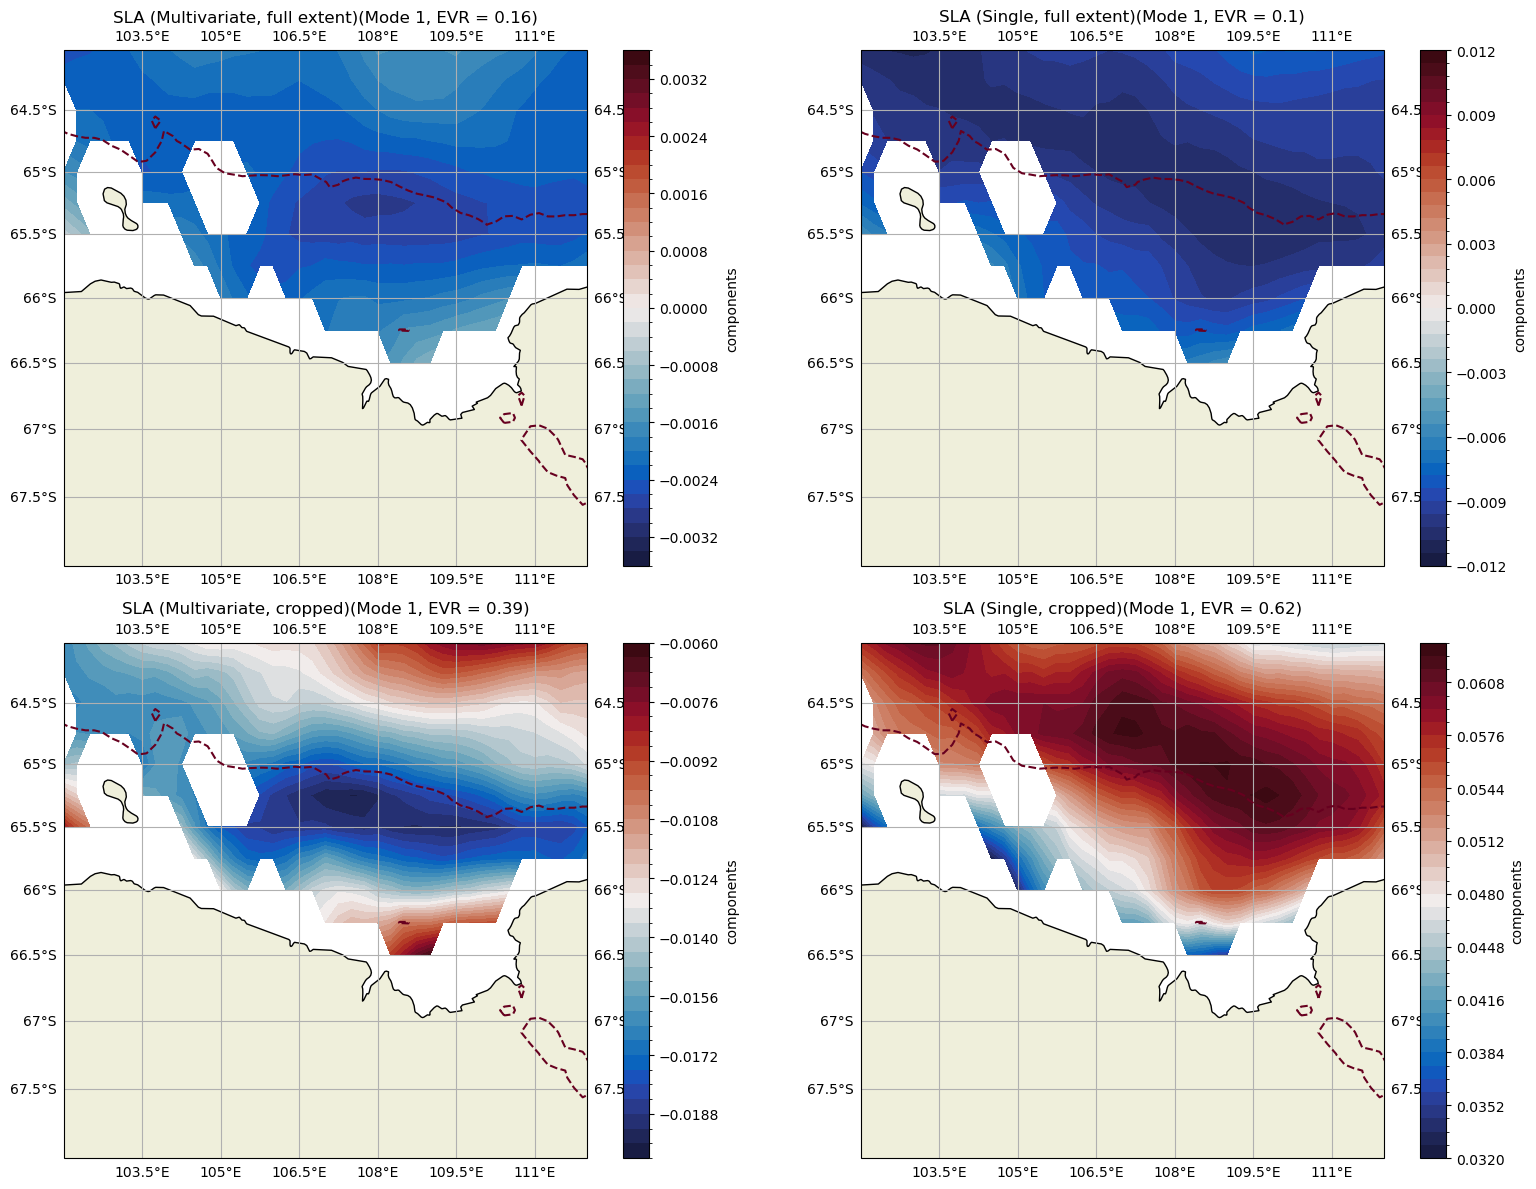

In [20]:
multivariate_data = prepare_data(extent_vincennes)
multivariate_data_mi = prepare_data(extent_mi)
sla_data = multivariate_data[0]
sla_data_mi = multivariate_data_mi[0]


components_mm, scores_mm, evr_mm = eof_for_data(multivariate_data_mi)
components_me, scores_me, evr_me = eof_for_data(multivariate_data)
components_sm, scores_sm, evr_sm = eof_for_data(sla_data_mi)
components_se, scores_se, evr_se = eof_for_data(sla_data)
fig,axs = plt.subplots(2,2,figsize=(16,12),subplot_kw={'projection':ccrs.Mercator()})

# plot maps
def plot_component(ax,component,title,mode,evr):
    comp=component.sel(mode=mode)
    evr_=evr.sel(mode=mode).item()
    comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    ax.set_extent(extent_vincennes,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k')
    ax.gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
    ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

plot_component(axs[0][0],components_mm[0],'SLA (Multivariate, full extent)',mode=1,evr=evr_mm)
plot_component(axs[0][1],components_sm,'SLA (Single, full extent)',mode=1, evr = evr_sm)
plot_component(axs[1][0],components_me[0],'SLA (Multivariate, cropped)',mode=1,evr=evr_me)
plot_component(axs[1][1],components_se,'SLA (Single, cropped)',mode=1, evr = evr_se)

plt.tight_layout()

/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/users/eejco/miniforge3/envs/sha-env/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:1585: UserWarning:

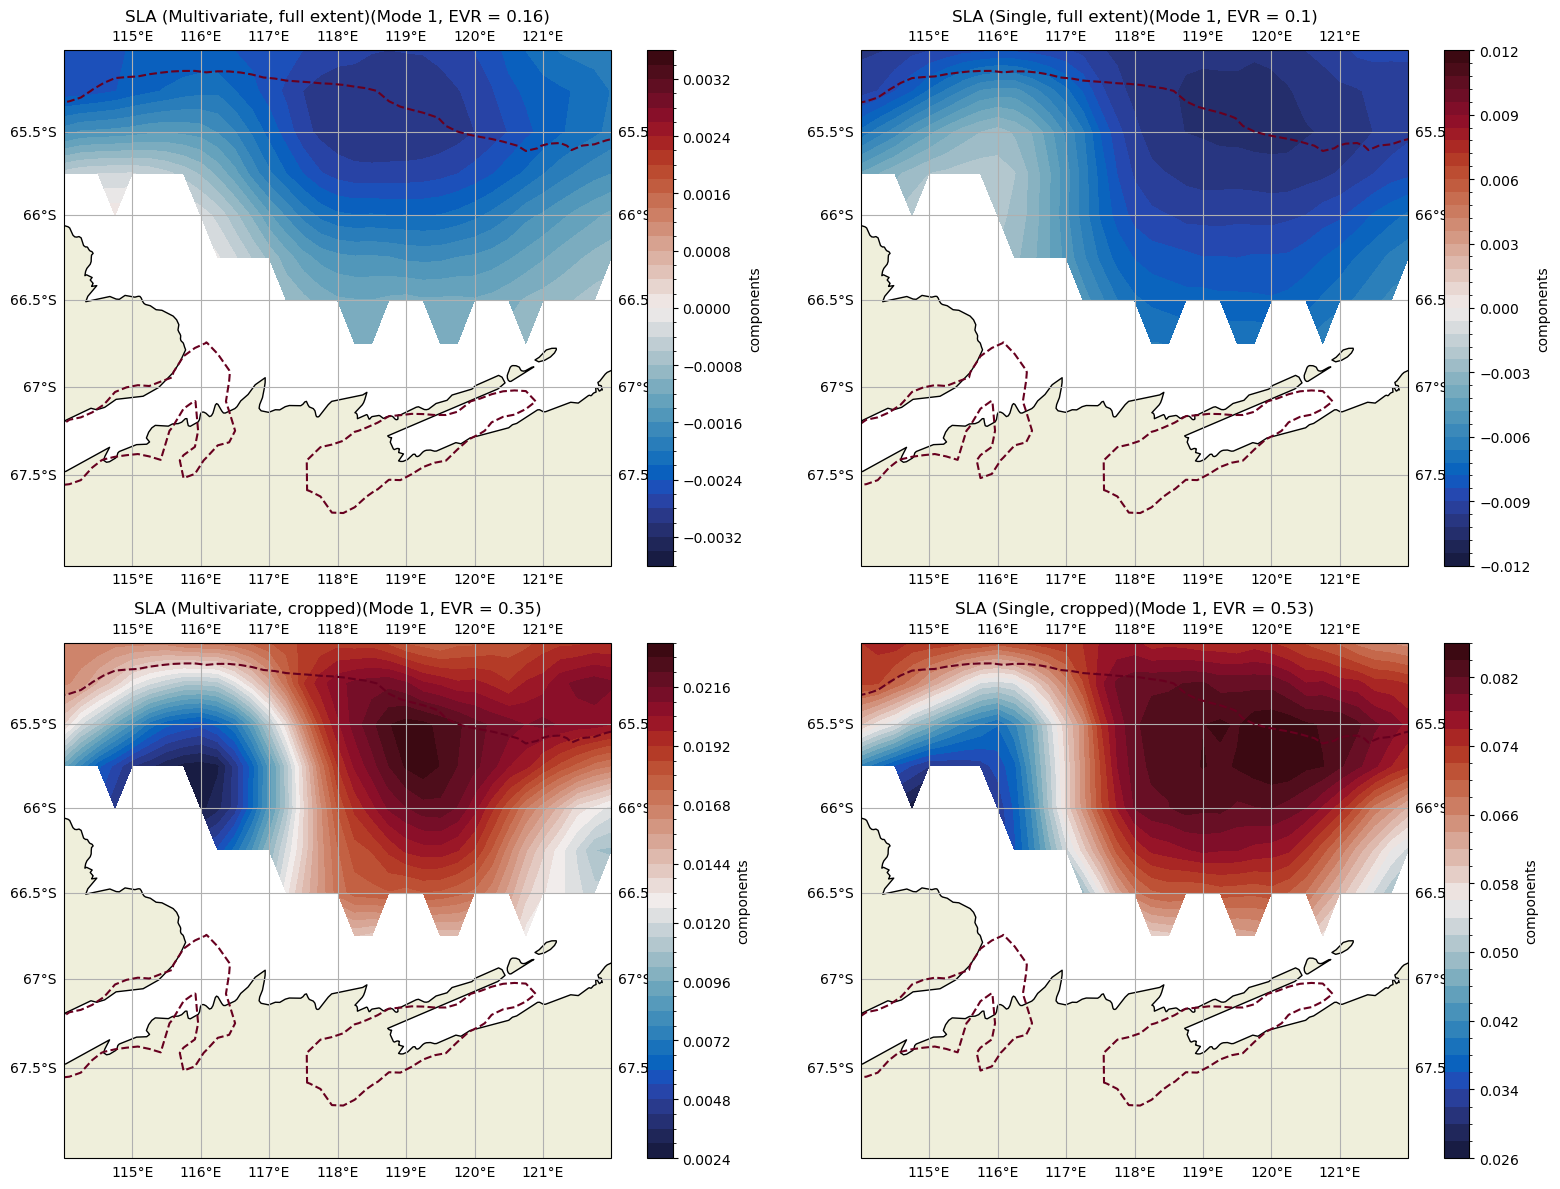

In [22]:
multivariate_data = prepare_data(extent_totten)
multivariate_data_mi = prepare_data(extent_mi)
sla_data = multivariate_data[0]
sla_data_mi = multivariate_data_mi[0]


components_mm, scores_mm, evr_mm = eof_for_data(multivariate_data_mi)
components_me, scores_me, evr_me = eof_for_data(multivariate_data)
components_sm, scores_sm, evr_sm = eof_for_data(sla_data_mi)
components_se, scores_se, evr_se = eof_for_data(sla_data)
fig,axs = plt.subplots(2,2,figsize=(16,12),subplot_kw={'projection':ccrs.Mercator()})

# plot maps
def plot_component(ax,component,title,mode,evr):
    comp=component.sel(mode=mode)
    evr_=evr.sel(mode=mode).item()
    comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    ax.set_extent(extent_totten,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k')
    ax.gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
    ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

plot_component(axs[0][0],components_mm[0],'SLA (Multivariate, full extent)',mode=1,evr=evr_mm)
plot_component(axs[0][1],components_sm,'SLA (Single, full extent)',mode=1, evr = evr_sm)
plot_component(axs[1][0],components_me[0],'SLA (Multivariate, cropped)',mode=1,evr=evr_me)
plot_component(axs[1][1],components_se,'SLA (Single, cropped)',mode=1, evr = evr_se)

plt.tight_layout()

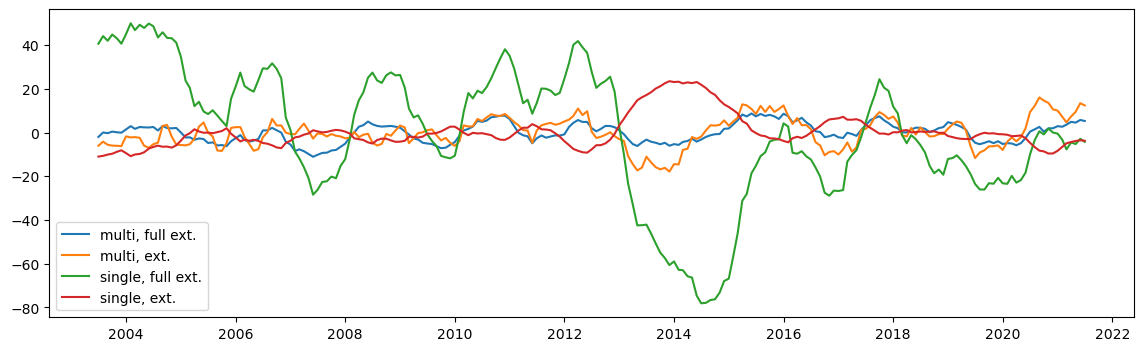

In [21]:
fig,ax = plt.subplots(figsize=(14,4))
ax.plot(scores_mm.time,scores_mm.sel(mode=1).rolling({'time':12},center=True).mean()/10,label='multi, full ext.')
ax.plot(scores_mm.time,scores_me.sel(mode=1).rolling({'time':12},center=True).mean(),label='multi, ext.')
ax.plot(scores_mm.time,scores_sm.sel(mode=1).rolling({'time':12},center=True).mean(),label='single, full ext.')
ax.plot(scores_mm.time,scores_se.sel(mode=1).rolling({'time':12},center=True).mean(),label='single, ext.')
ax.legend()


In [23]:
scores_me.attrs.clear()
scores_mm.attrs.clear()
scores_se.attrs.clear()
scores_sm.attrs.clear()


In [ ]:
scores_me.to_netcdf('gye_index_eof_me.nc')
scores_mm.to_netcdf('gye_index_eof_mm.nc')
scores_sm.to_netcdf('gye_index_eof_sm.nc')
scores_se.to_netcdf('gye_index_eof_se.nc')


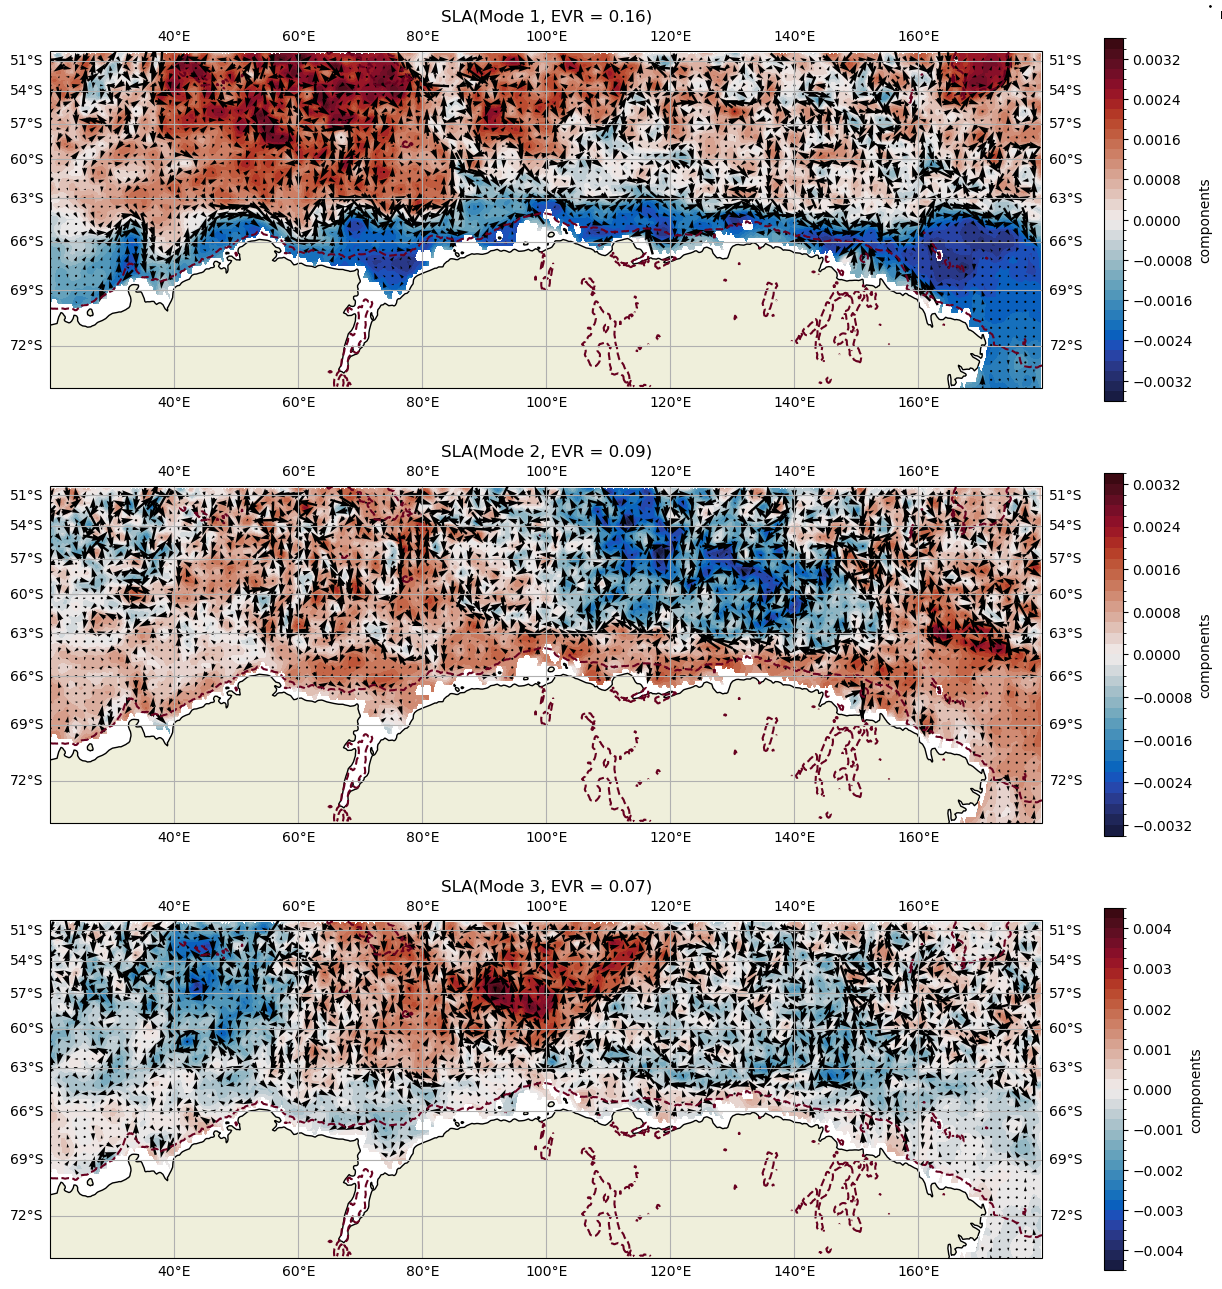

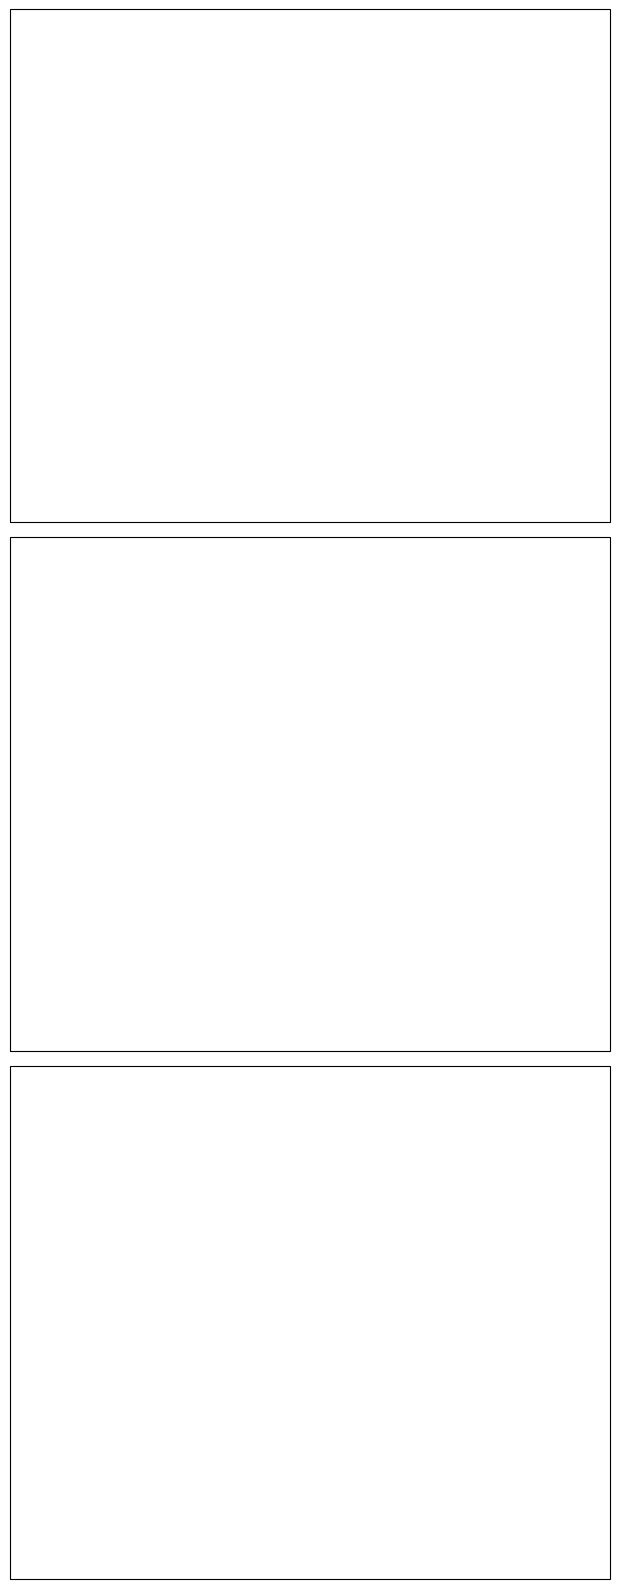

In [36]:


fig,axs = plt.subplots(3,1,figsize=(16,16),subplot_kw={'projection':ccrs.Mercator()})

# plot maps
def plot_component(ax,component,title,mode,u,v):
    comp=component.sel(mode=mode)
    evr_=evr.sel(mode=mode).item()
    comp.plot.contourf(x='longitude',y='latitude',ax=ax,cmap=cmocean.cm.balance,transform=ccrs.PlateCarree(),levels=40)
    ax.set_extent(extent_mi,crs=ccrs.PlateCarree())
    ax.add_feature(LAND, edgecolor='k')
    ax.gridlines(draw_labels=True)
    elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
    ds =xr.Dataset({'u10':u,'v10':v})
    ds.plot.quiver(ax=ax,x='longitude',y='latitude',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=40)
    ax.set_title(title + '(Mode {0}, EVR = {1})'.format(mode,round(evr_,2)))

for i, ax in enumerate(axs) :
    mode = i + 1
    ug, vg = get_geostrophic_currents(components_mm[0].sel(mode=mode))
    plot_component(ax,components[0],'SLA',mode=i+1,u=ug,v=vg)

#plot with geostrophic currents
fig,axs = plt.subplots(3,1,figsize=(16,16),subplot_kw={'projection':ccrs.Mercator()})
for i, ax in enumerate(axs) :
    mode = i + 1
    #plot_component(ax,components[1],'SIC',mode=i+1,u=components[2].sel(mode=mode),v=components[3].sel(mode=mode))


plt.tight_layout()


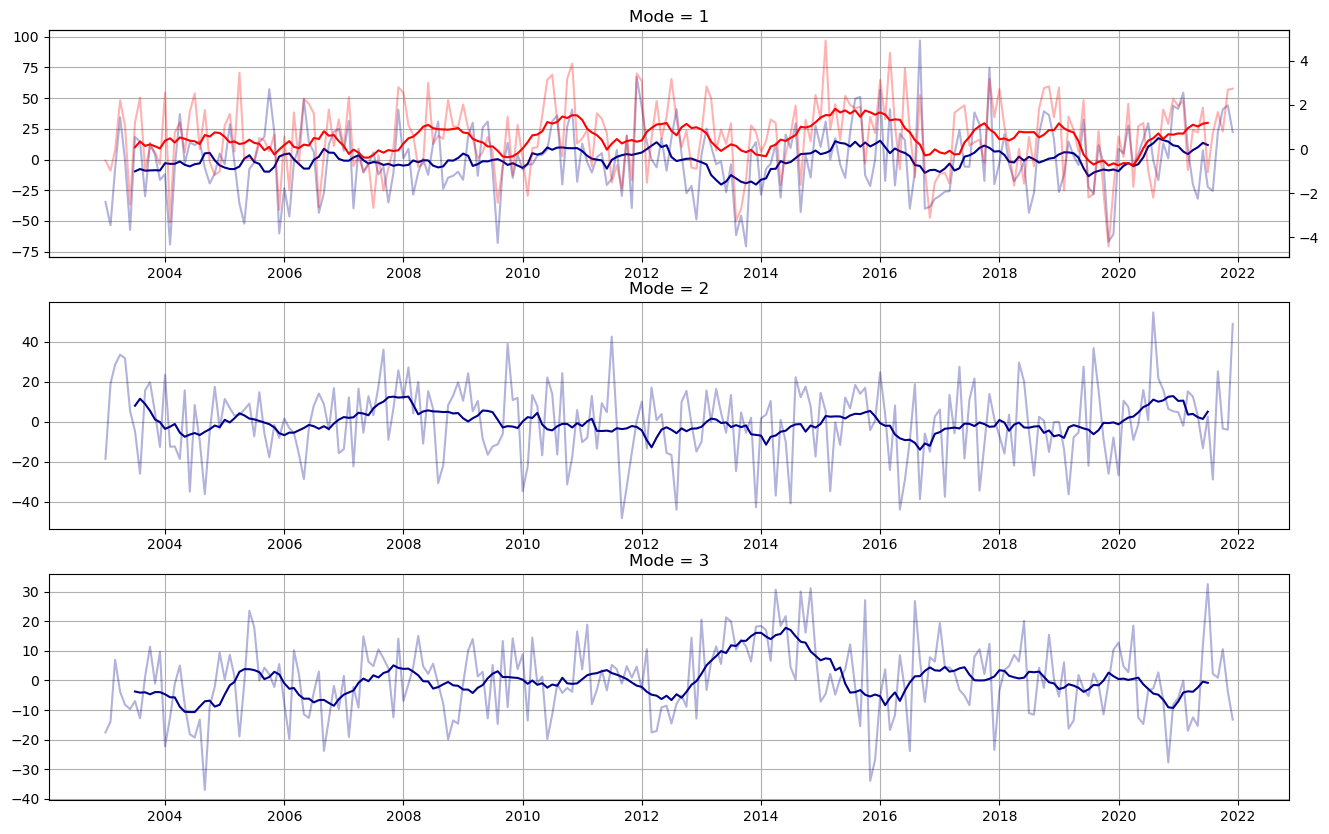

In [24]:
fig,axs = plt.subplots(3,1,figsize=(16,10))
for i in np.arange(3):
    axs[i].plot(scores.time,scores.sel(mode=i+1),c='darkblue',alpha=0.3)
    l1= axs[i].plot(scores.time,scores.sel(mode=i+1).rolling({'time':12},center=True).mean(),c='darkblue',label='scores')
    axs[i].set_title('Mode = {}'.format(i+1))
    axs[i].grid()
    if i==0:
        a2=axs[i].twinx()
        a2.plot(sam.time,sam,c='r',alpha=0.3)
        l2 = a2.plot(sam.time,sam.rolling({'time':12},center=True).mean(),c='r',label='SAM index')
        #axs[i].legend(l1+l2,['scores','SAM idx'],loc='best')


In [18]:
del scores.attrs['solver_kwargs']

In [121]:
scores.sel(mode=1).to_netcdf('scores_eof1.nc')
scores.sel(mode=2).to_netcdf('scores_eof2.nc')
scores.sel(mode=3).to_netcdf('scores_eof3.nc')


In [43]:
mca = xf.cross.MCA(n_modes=20, standardize=False, use_coslat=True)
mca.fit(da_sic,da_u10, dim="time")

In [32]:
singular_vectors = mca.components()
scores = mca.scores()
hom_pats, pvals_hom = mca.homogeneous_patterns()
het_pats, pvals_het = mca.heterogeneous_patterns()

In [33]:
hom_mask = [values < 0.05 for values in pvals_hom]
het_mask = [values < 0.05 for values in pvals_het]

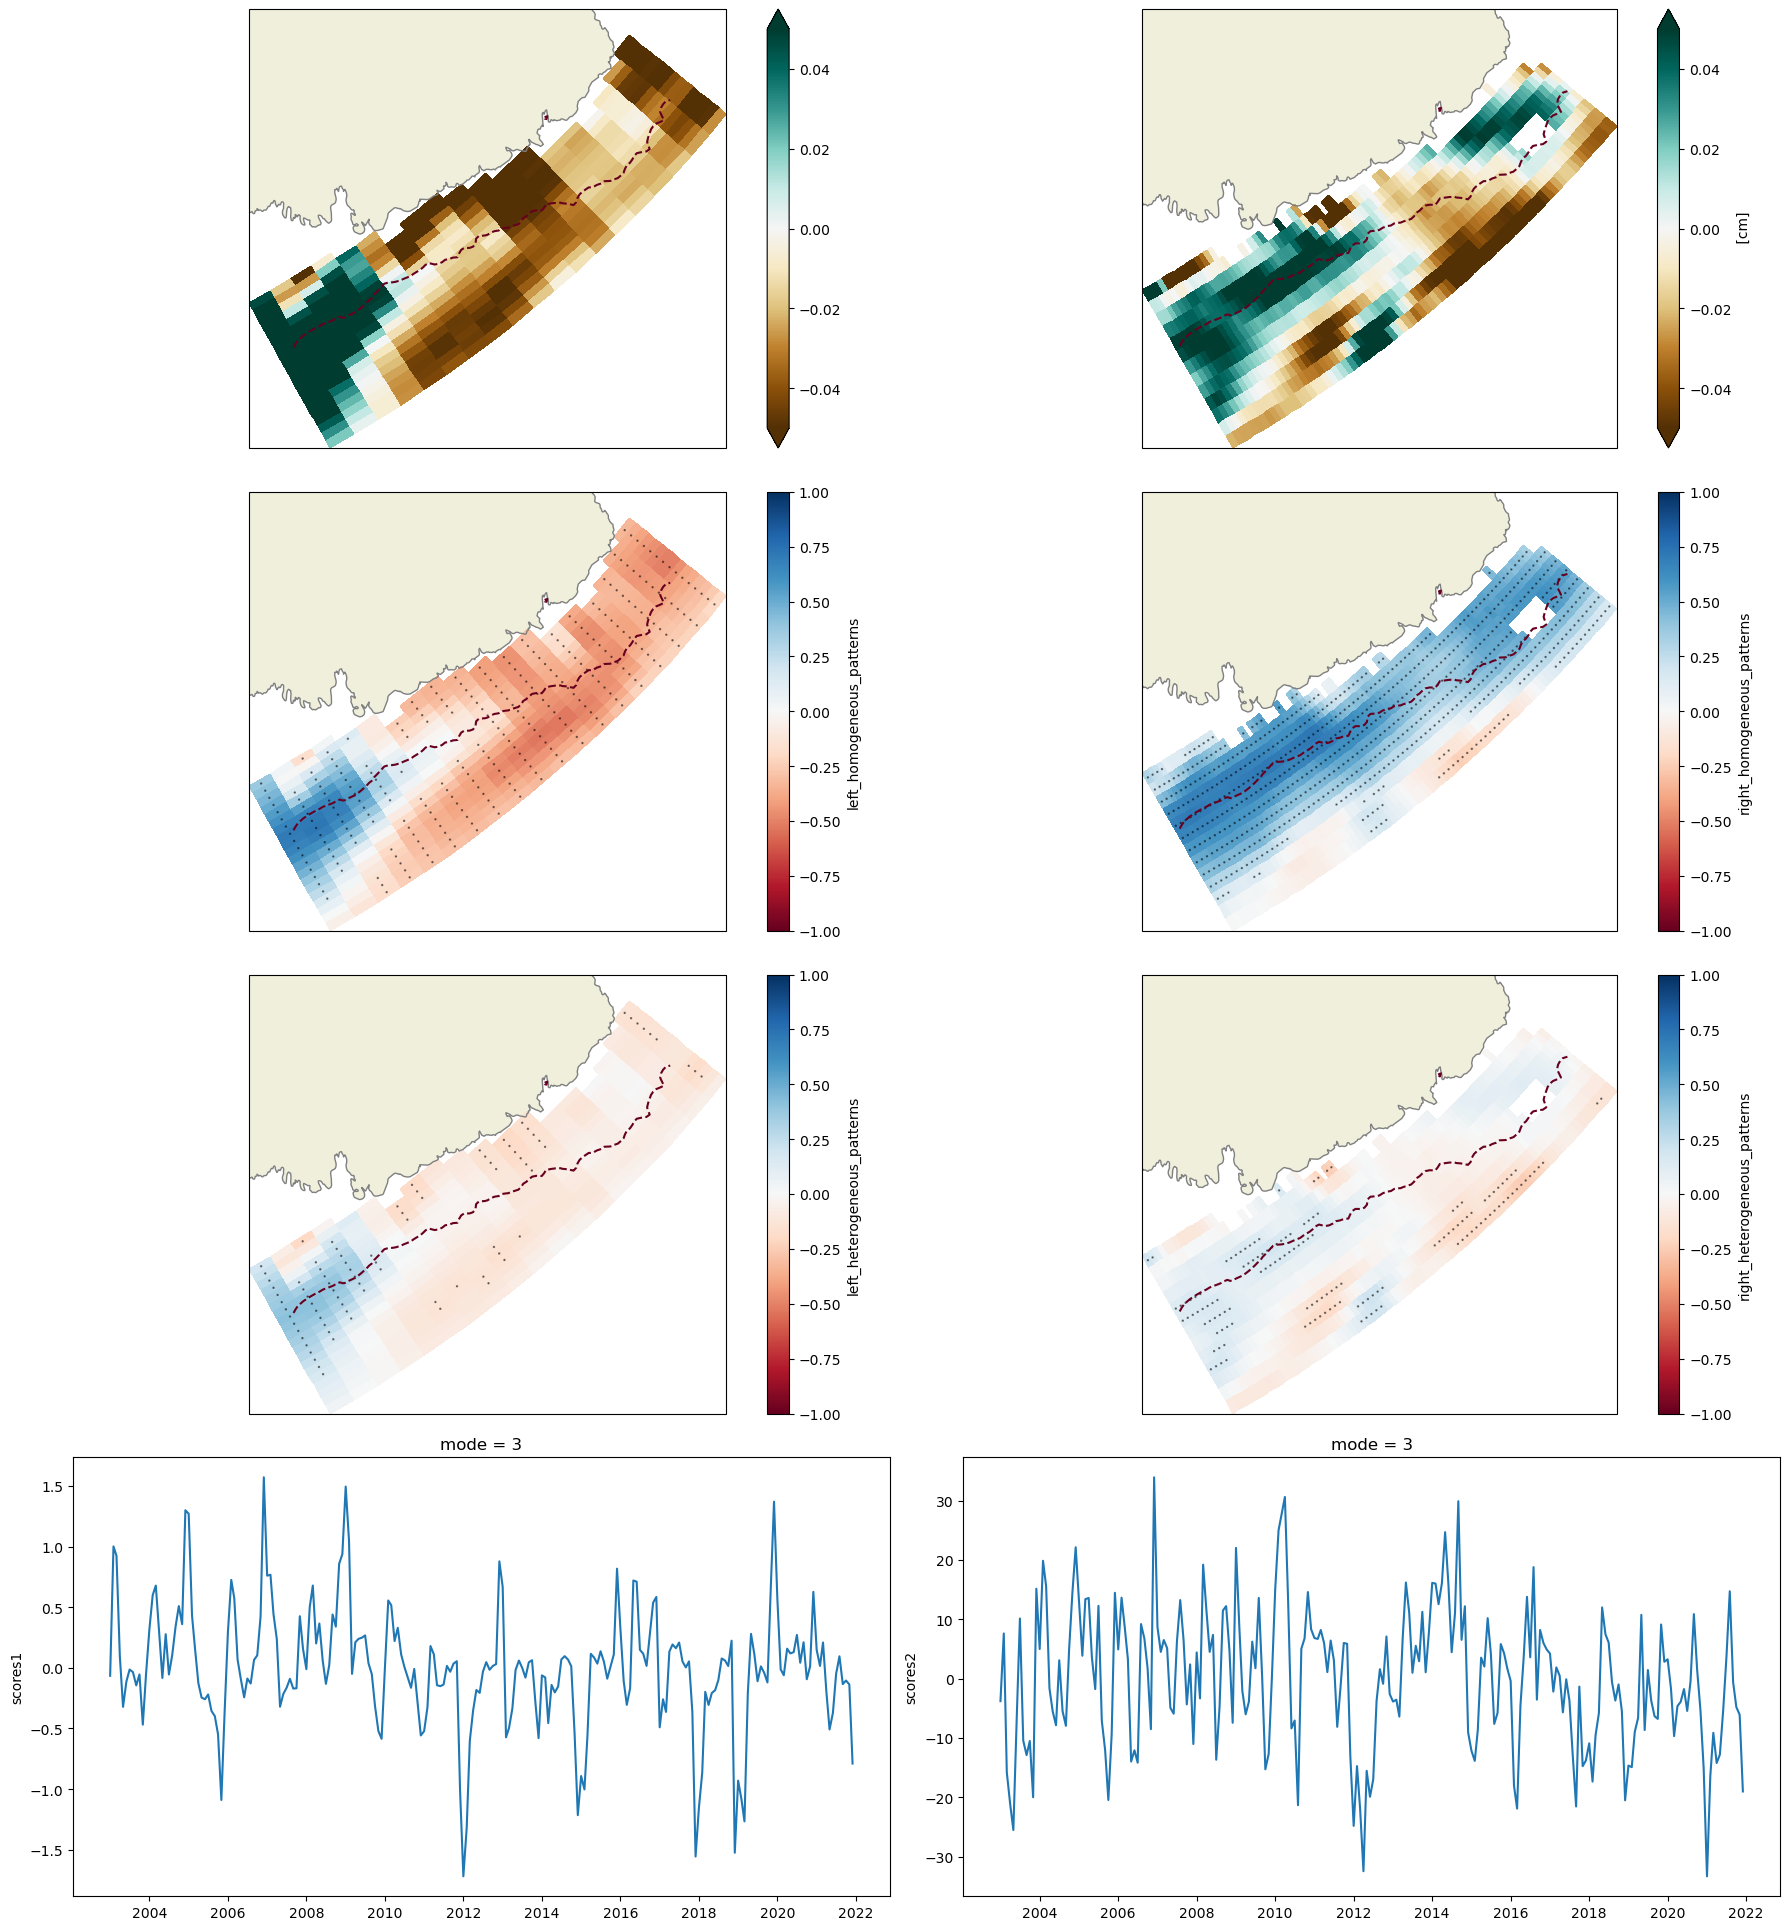

In [36]:
from matplotlib.gridspec import GridSpec

plot_isobath = lambda ax: elevation.plot.contour(x='longitude',y='latitude',ax=ax,transform=ccrs.PlateCarree(),levels=[-1000],linestyle='--',c='k')
lonlats = [
    np.meshgrid(pvals_hom[0].longitude.values, pvals_hom[0].latitude.values),
    np.meshgrid(pvals_hom[1].longitude.values, pvals_hom[1].latitude.values),
]
proj = [
    # Orthographic(central_latitude=30, central_longitude=-120),
    # Orthographic(central_latitude=30, central_longitude=-60),
    ccrs.SouthPolarStereo(),
    ccrs.SouthPolarStereo()
]
kwargs1 = {"cmap": "BrBG", "vmin": -0.05, "vmax": 0.05, "transform": ccrs.PlateCarree()}
kwargs2 = {"cmap": "RdBu", "vmin": -1, "vmax": 1, "transform": ccrs.PlateCarree()}

mode = 3

fig = plt.figure(figsize=(18,24))
gs = GridSpec(5, 2)
ax1 = [fig.add_subplot(gs[0, i], projection=proj[i]) for i in range(2)]
ax2 = [fig.add_subplot(gs[1, i], projection=proj[i]) for i in range(2)]
ax3 = [fig.add_subplot(gs[2, i], projection=proj[i]) for i in range(2)]
ax4 = [fig.add_subplot(gs[3, i]) for i in range(2)]

for i, a in enumerate(ax1):
    singular_vectors[i].sel(mode=mode).plot(ax=a, **kwargs1)

for i, a in enumerate(ax2):
    hom_pats[i].sel(mode=mode).plot(ax=a, **kwargs2)
    a.scatter(
        lonlats[i][0],
        lonlats[i][1],
        hom_mask[i].sel(mode=mode).values * 0.5,
        color="k",
        alpha=0.5,
        transform=ccrs.PlateCarree(),
    )

for i, a in enumerate(ax3):
    het_pats[i].sel(mode=mode).plot(ax=a, **kwargs2)
    a.scatter(
        lonlats[i][0],
        lonlats[i][1],
        het_mask[i].sel(mode=mode).values * 0.5,
        color="k",
        alpha=0.5,
        transform=ccrs.PlateCarree(),
    )

for i, a in enumerate(ax4):
    scores[i].sel(mode=mode).plot(ax=a)
    a.set_xlabel("")


for a in np.ravel([ax1, ax2, ax3]):
    a.coastlines(color=".5")
    a.add_feature(LAND)
    plot_isobath(a)

plt.tight_layout()
